In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json
import os

os.chdir("../")
from scripts import utils
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.svm import OneClassSVM
import distclassipy as dcpy
from distclassipy.anomaly import DistanceAnomaly

from sklearn.base import BaseEstimator, OutlierMixin
epsilon = np.finfo(np.float32).eps
with open("settings.txt") as f:
    settings_dict = json.load(f)
seed_val = settings_dict["seed_choice"]
np.random.seed(seed_val)
sns_dict = settings_dict["sns_dict"]
sns.set_theme(**sns_dict)

from IPython.core.display import HTML
import squarify
set3colors = [matplotlib.colors.rgb2hex(x) for x in plt.cm.Set3.colors]
knowncolors = set3colors[:4]
unknowncolors = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabed4', '#469990', '#dcbeff', '#9A6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#a9a9a9']
unknowncolors = set3colors[4:]+unknowncolors

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, OutlierMixin
from sklearn.model_selection import train_test_split
from types import SimpleNamespace
import copy

In [2]:

# ----------------------------------------------------------------------------
# EarlyStopping Helper Class
# ----------------------------------------------------------------------------
class EarlyStopping:
    """
    Early stops the training if validation loss doesn't improve after a given patience.
    """
    def __init__(self, patience=5, min_delta=0, verbose=False):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
                            Default: 5
            min_delta (float): Minimum change in the monitored quantity to qualify as an improvement.
                               Default: 0
            verbose (bool): If True, prints a message for each validation loss improvement. 
                            Default: False
        """
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_state_dict = None

    def __call__(self, val_loss, model):
        # Check if the validation loss has improved
        if self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            # Save the best model state using a deep copy
            self.best_model_state_dict = copy.deepcopy(model.state_dict())
            if self.verbose:
                print(f"Validation loss decreased ({self.best_loss:.6f}). Saving model...")
        else:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                print("Early stopping triggered.")
                self.early_stop = True

# ----------------------------------------------------------------------------
# PyTorch Autoencoder Model Definition (from your Autoencoder.py file)
# ----------------------------------------------------------------------------
class ae(nn.Module):
    """Pytorch implementation of an autoencoder based on MLP."""

    def __init__(self, args):
        super(ae, self).__init__()

        self.args = args
        # Encoder Architecture
        self.enc1 = nn.Linear(args.in_dim, 512)
        self.encbn1 = nn.BatchNorm1d(512)
        self.enc2 = nn.Linear(512, 256)
        self.encbn2 = nn.BatchNorm1d(256)
        self.enc3 = nn.Linear(256, 128)
        self.encbn3 = nn.BatchNorm1d(128)
        self.enc4 = nn.Linear(128, args.z_dim, bias=False)

        # Decoder Architecture
        self.dec1 = nn.Linear(args.z_dim, 128)
        self.decbn1 = nn.BatchNorm1d(128)
        self.dec2 = nn.Linear(128, 256)
        self.decbn2 = nn.BatchNorm1d(256)
        self.dec3 = nn.Linear(256, 512)
        self.decbn3 = nn.BatchNorm1d(512)
        self.dec4 = nn.Linear(512, args.in_dim)

    def encode(self, x):
        h = F.leaky_relu(self.encbn1(self.enc1(x)))
        h = F.leaky_relu(self.encbn2(self.enc2(h)))
        h = F.leaky_relu(self.encbn3(self.enc3(h)))
        return self.enc4(h)

    def decode(self, x):
        h = F.leaky_relu(self.decbn1(self.dec1(x)))
        h = F.leaky_relu(self.decbn2(self.dec2(h)))
        h = F.leaky_relu(self.decbn3(self.dec3(h)))
        return torch.tanh(self.dec4(h))

    def forward(self, x):
        """Forward pass over the network architecture"""
        z = self.encode(x)
        x_hat = self.decode(z)
        return z, x_hat

    def compute_loss(self, x):
        """
        Compute MSE Loss.
        """
        _, x_hat = self.forward(x)
        loss = F.mse_loss(x_hat, x, reduction='mean')
        return loss

    def compute_anomaly_score(self, x):
        """
        Computing the anomaly score for each sample x.
        """
        _, x_hat = self.forward(x)
        # Calculates reconstruction error for each sample
        score = F.mse_loss(x_hat, x, reduction='none')
        # The anomaly score is the sum of squared errors across all features
        return torch.sum(score, dim=1)

# ----------------------------------------------------------------------------
# scikit-learn compatible Anomaly Detector using the PyTorch AE with EarlyStopping
# ----------------------------------------------------------------------------
class AutoencoderAnomalyDetector(BaseEstimator, OutlierMixin):
    def __init__(self, encoding_dim=16, epochs=50, batch_size=32, lr=1e-4, 
                 validation_split=0.1, patience=5, verbose=False):
        self.encoding_dim = encoding_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.validation_split = validation_split
        self.patience = patience
        self.verbose = verbose
        self.model_ = None

    def fit(self, X, y=None):
        # Infer input dimension from data
        input_dim = X.shape[1]
        
        # Create a namespace for model arguments, mimicking the 'args' object
        model_args = SimpleNamespace(in_dim=input_dim, z_dim=self.encoding_dim)
        
        # Instantiate the PyTorch model
        self.model_ = ae(model_args)
        
        # Split data into training and validation sets
        X_train, X_val = train_test_split(X, test_size=self.validation_split, random_state=42)

        # Convert numpy data to PyTorch tensors
        X_train_tensor = torch.from_numpy(X_train.astype(np.float32))
        X_val_tensor = torch.from_numpy(X_val.astype(np.float32))

        # Create DataLoaders for batching
        train_dataset = TensorDataset(X_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        
        val_dataset = TensorDataset(X_val_tensor)
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)

        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        early_stopper = EarlyStopping(patience=self.patience, verbose=self.verbose)
        
        # Training loop
        for epoch in tqdm(range(self.epochs), leave=False, desc="Training AE"):
            # --- Training Step ---
            self.model_.train()
            for batch in train_loader:
                inputs = batch[0]
                optimizer.zero_grad()
                loss = self.model_.compute_loss(inputs)
                loss.backward()
                optimizer.step()

            # --- Validation Step ---
            self.model_.eval()
            validation_loss = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    inputs = batch[0]
                    loss = self.model_.compute_loss(inputs)
                    validation_loss += loss.item()
            
            avg_val_loss = validation_loss / len(val_loader)
            
            # --- Early Stopping Check ---
            early_stopper(avg_val_loss, self.model_)
            if early_stopper.early_stop:
                break
        
        # Load the best model state found during training
        if early_stopper.best_model_state_dict:
            self.model_.load_state_dict(early_stopper.best_model_state_dict)
        
        return self

    def decision_function(self, X):
        if self.model_ is None:
            raise RuntimeError("The model has not been fitted yet.")
        
        self.model_.eval()
        X_tensor = torch.from_numpy(X.astype(np.float32))
        
        with torch.no_grad():
            scores = self.model_.compute_anomaly_score(X_tensor)
            
        return scores.detach().cpu().numpy()

In [3]:
# ----------------------------------------------------------------------------
# PyTorch Variational Autoencoder Model Definition
# ----------------------------------------------------------------------------
class vae(nn.Module):
    """Pytorch implementation of a variational autoencoder based on MLP."""

    def __init__(self, args):
        super(vae, self).__init__()

        # Encoder Architecture
        self.enc1 = nn.Linear(args.in_dim, 512)
        self.encbn1 = nn.BatchNorm1d(512)
        self.enc2 = nn.Linear(512, 256)
        self.encbn2 = nn.BatchNorm1d(256)
        self.enc3 = nn.Linear(256, 128)
        self.encbn3 = nn.BatchNorm1d(128)

        self.mu = nn.Linear(128, args.z_dim)
        self.log_var = nn.Linear(128, args.z_dim)

        # Decoder Architecture
        self.dec1 = nn.Linear(args.z_dim, 128)
        self.decbn1 = nn.BatchNorm1d(128)
        self.dec2 = nn.Linear(128, 256)
        self.decbn2 = nn.BatchNorm1d(256)
        self.dec3 = nn.Linear(256, 512)
        self.decbn3 = nn.BatchNorm1d(512)
        self.dec4 = nn.Linear(512, args.in_dim)

    def encode(self, x):
        h = F.leaky_relu(self.encbn1(self.enc1(x)))
        h = F.leaky_relu(self.encbn2(self.enc2(h)))
        h = F.leaky_relu(self.encbn3(self.enc3(h)))
        return self.mu(h), self.log_var(h)

    def decode(self, x):
        h = F.leaky_relu(self.decbn1(self.dec1(x)))
        h = F.leaky_relu(self.decbn2(self.dec2(h)))
        h = F.leaky_relu(self.decbn3(self.dec3(h)))
        return torch.tanh(self.dec4(h))

    def reparameterize(self, mu, log_var):
        std = torch.exp(log_var / 2)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_hat = self.decode(z)
        return mu, log_var, z, x_hat

    def compute_loss(self, x, L=1):
        """
        Compute Evidence Lower Bound (ELBO) for the variational autoencoder.
        L is the number of Monte Carlo samples for reconstruction.
        """
        mu, log_var = self.encode(x)

        # KL Divergence
        dkl = torch.mean(-0.5 * (1 + log_var - mu.pow(2) - log_var.exp()))

        # Reconstruction Loss (averaged over L samples)
        rec_loss = 0
        for _ in range(L):
            z = self.reparameterize(mu, log_var)
            x_hat = self.decode(z)
            rec_loss += F.mse_loss(x_hat, x, reduction='mean')
        
        reconstruction = rec_loss / L
        
        loss = reconstruction + dkl
        return loss

    def compute_anomaly_score(self, x):
        """
        Computing the anomaly score for each sample x using reconstruction error.
        """
        # The forward pass in evaluation mode will use a single z sample
        _, _, _, x_hat = self.forward(x)
        score = F.mse_loss(x_hat, x, reduction='none')
        # The anomaly score is the sum of squared errors across all features
        return torch.sum(score, dim=1)

# ----------------------------------------------------------------------------
# scikit-learn compatible Anomaly Detector using the PyTorch VAE with EarlyStopping
# ----------------------------------------------------------------------------
class VAEAnomalyDetector(BaseEstimator, OutlierMixin):
    def __init__(self, encoding_dim=16, epochs=50, batch_size=32, lr=1e-4,
                 loss_samples=1, validation_split=0.1, patience=5, verbose=False):
        self.encoding_dim = encoding_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.loss_samples = loss_samples # Number of MC samples (L) for loss calc
        self.validation_split = validation_split
        self.patience = patience
        self.verbose = verbose
        self.model_ = None

    def fit(self, X, y=None):
        # Infer input dimension from data
        input_dim = X.shape[1]
        
        # Create a namespace for model arguments, mimicking the 'args' object
        model_args = SimpleNamespace(in_dim=input_dim, z_dim=self.encoding_dim)
        
        # Instantiate the PyTorch model
        self.model_ = vae(model_args)
        
        # Split data into training and validation sets
        X_train, X_val = train_test_split(X, test_size=self.validation_split, random_state=42)

        # Convert numpy data to PyTorch tensors
        X_train_tensor = torch.from_numpy(X_train.astype(np.float32))
        X_val_tensor = torch.from_numpy(X_val.astype(np.float32))

        # Create DataLoaders for batching
        train_dataset = TensorDataset(X_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        
        val_dataset = TensorDataset(X_val_tensor)
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)

        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        early_stopper = EarlyStopping(patience=self.patience, verbose=self.verbose)
        
        # Training loop
        for epoch in tqdm(range(self.epochs), leave=False, desc="Training VAE"):
            # --- Training Step ---
            self.model_.train()
            for batch in train_loader:
                inputs = batch[0]
                optimizer.zero_grad()
                loss = self.model_.compute_loss(inputs, L=self.loss_samples)
                loss.backward()
                optimizer.step()

            # --- Validation Step ---
            self.model_.eval()
            validation_loss = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    inputs = batch[0]
                    # Use a single sample for validation loss for speed and consistency
                    loss = self.model_.compute_loss(inputs, L=1)
                    validation_loss += loss.item()
            
            avg_val_loss = validation_loss / len(val_loader)
            
            # --- Early Stopping Check ---
            early_stopper(avg_val_loss, self.model_)
            if early_stopper.early_stop:
                if self.verbose:
                    print(f"Early stopping triggered at epoch {epoch+1}")
                break
        
        # Load the best model state found during training
        if early_stopper.best_model_state_dict:
            self.model_.load_state_dict(early_stopper.best_model_state_dict)
        
        return self

    def decision_function(self, X):
        if self.model_ is None:
            raise RuntimeError("The model has not been fitted yet.")
        
        self.model_.eval()
        X_tensor = torch.from_numpy(X.astype(np.float32))
        
        with torch.no_grad():
            scores = self.model_.compute_anomaly_score(X_tensor)
            
        return scores.detach().cpu().numpy()


In [4]:
# ----------------------------------------------------------------------------
# PyTorch Deep SVDD Model Definition
# ----------------------------------------------------------------------------
class DeepSVDD_torch(nn.Module):
    """Pytorch implementation of Deep SVDD."""

    def __init__(self, args):
        super(DeepSVDD_torch, self).__init__()

        self.args = args
        # Encoder Architecture
        self.enc1 = nn.Linear(args.in_dim, 512)
        self.encbn1 = nn.BatchNorm1d(512)
        self.enc2 = nn.Linear(512, 256)
        self.encbn2 = nn.BatchNorm1d(256)
        self.enc3 = nn.Linear(256, 128)
        self.encbn3 = nn.BatchNorm1d(128)
        self.enc4 = nn.Linear(128, args.z_dim, bias=False)

    def encode(self, x):
        h = F.leaky_relu(self.encbn1(self.enc1(x)))
        h = F.leaky_relu(self.encbn2(self.enc2(h)))
        h = F.leaky_relu(self.encbn3(self.enc3(h)))
        return self.enc4(h)
    
    def forward(self, x):
        """Forward pass over the network architecture"""
        z = self.encode(x)
        return z

    def compute_loss(self, x, c):
        """
        Compute Deep SVDD objective.
        """
        z = self.forward(x)
        loss = torch.mean(torch.sum((z - c) ** 2, dim=1))
        return loss

    def compute_anomaly_score(self, x, c):
        """
        Computing the anomaly score for each sample x.
        """
        z = self.forward(x)
        score = torch.sum((z - c) ** 2, dim=1)
        return score

# ----------------------------------------------------------------------------
# scikit-learn compatible Anomaly Detector using the PyTorch DeepSVDD
# ----------------------------------------------------------------------------
class DeepSVDDAnomalyDetector(BaseEstimator, OutlierMixin):
    def __init__(self, encoding_dim=16, epochs=50, batch_size=32, lr=1e-4, 
                 validation_split=0.1, patience=5, verbose=False):
        self.encoding_dim = encoding_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.validation_split = validation_split
        self.patience = patience
        self.verbose = verbose
        self.model_ = None
        self.c_ = None # Center of the hypersphere

    def _init_center_c(self, train_loader, eps=0.01):
        """Initializes the center c to the mean of the network outputs of the training data."""
        self.model_.eval()
        zs = []
        with torch.no_grad():
            for batch in train_loader:
                inputs = batch[0]
                z = self.model_(inputs)
                zs.append(z.detach())
        zs = torch.cat(zs)
        c = torch.mean(zs, dim=0)
        # If c is too close to 0, set to a small value eps to avoid trivial solution
        c[(abs(c) < eps) & (c < 0)] = -eps
        c[(abs(c) < eps) & (c > 0)] = eps
        return c

    def fit(self, X, y=None):
        # --- 0. Label Encoding ---
        # Convert string labels (like 'RRL') to integer labels (0, 1, 2, ...)
        self.label_encoder_ = LabelEncoder()
        y_encoded = self.label_encoder_.fit_transform(y.ravel()) # Use ravel() to ensure 1D array

        # Infer input dimension from data
        input_dim = X.shape[1]
        
        # Create a namespace for model arguments
        model_args = SimpleNamespace(in_dim=input_dim, z_dim=self.encoding_dim)
        
        # Instantiate the PyTorch model
        self.model_ = DeepSVDD_torch(model_args)
            
        # Split data into training and validation sets
        X_train, X_val, y_train, y_val = train_test_split(
            X, y_encoded, test_size=self.validation_split, random_state=42, stratify=y_encoded
        )
        
        # Convert numpy data to PyTorch tensors
        X_train_tensor = torch.from_numpy(X_train.astype(np.float32))
        X_val_tensor = torch.from_numpy(X_val.astype(np.float32))

        # Create DataLoaders for batching
        train_dataset = TensorDataset(X_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        
        val_dataset = TensorDataset(X_val_tensor)
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)

        # Initialize hypersphere center c
        self.c_ = self._init_center_c(train_loader)

        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        early_stopper = EarlyStopping(patience=self.patience, verbose=self.verbose)
        
        # Training loop
        for epoch in tqdm(range(self.epochs), leave=False, desc="Training DeepSVDD"):
            # --- Training Step ---
            self.model_.train()
            for batch in train_loader:
                inputs = batch[0]
                optimizer.zero_grad()
                loss = self.model_.compute_loss(inputs, self.c_)
                loss.backward()
                optimizer.step()

            # --- Validation Step ---
            self.model_.eval()
            validation_loss = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    inputs = batch[0]
                    loss = self.model_.compute_loss(inputs, self.c_)
                    validation_loss += loss.item()
            
            avg_val_loss = validation_loss / len(val_loader)
            
            # --- Early Stopping Check ---
            early_stopper(avg_val_loss, self.model_)
            if early_stopper.early_stop:
                break
        
        # Load the best model state found during training
        if early_stopper.best_model_state_dict:
            self.model_.load_state_dict(early_stopper.best_model_state_dict)
        
        return self

    def decision_function(self, X):
        if self.model_ is None or self.c_ is None:
            raise RuntimeError("The model has not been fitted yet.")
        
        self.model_.eval()
        X_tensor = torch.from_numpy(X.astype(np.float32))
        
        with torch.no_grad():
            scores = self.model_.compute_anomaly_score(X_tensor, self.c_)
            
        return scores.detach().cpu().numpy()

In [5]:
# ----------------------------------------------------------------------------
# PyTorch Class-SVDD Model Definition
# ----------------------------------------------------------------------------
class ClassSVDD(nn.Module):
    """Pytorch implementation of a class-conditional SVDD based on MLP."""

    def __init__(self, args):
        super(ClassSVDD, self).__init__()

        self.args = args
        self.c = None # Center(s) of the hypersphere(s)

        # Encoder Architecture
        self.enc1 = nn.Linear(args.in_dim, 512)
        self.encbn1 = nn.BatchNorm1d(512)
        self.enc2 = nn.Linear(512, 256)
        self.encbn2 = nn.BatchNorm1d(256)
        self.enc3 = nn.Linear(256, 128)
        self.encbn3 = nn.BatchNorm1d(128)
        self.enc4 = nn.Linear(128, args.z_dim, bias=False)

    def encode(self, x):
        h = F.leaky_relu(self.encbn1(self.enc1(x)))
        h = F.leaky_relu(self.encbn2(self.enc2(h)))
        h = F.leaky_relu(self.encbn3(self.enc3(h)))
        return self.enc4(h)

    def forward(self, x):
        """Forward pass over the network architecture"""
        z = self.encode(x)
        return z

    def compute_loss(self, x, y):
        """
        Compute objective function: distance to class center.
        Requires self.c to be set.
        """
        if self.c is None:
            raise ValueError("Center 'c' is not initialized. Call 'init_center_c' before training.")
            
        z = self.forward(x)
        # Calculate distance to the center corresponding to the label 'y'
        loss = torch.mean(torch.sum((z - self.c[y]) ** 2, dim=1))
        return loss

    def compute_anomaly_score(self, x):
        """
        Computing the anomaly score for each sample x.
        The score is the distance to the *closest* class center.
        Requires self.c to be set.
        """
        if self.c is None:
            raise ValueError("Center 'c' is not initialized.")

        z = self.forward(x)
        # Calculate distance to all centers and take the minimum
        distances_to_centers = torch.sum((z.unsqueeze(1) - self.c) ** 2, dim=2)
        score = torch.min(distances_to_centers, dim=1)[0]
        return score

# ----------------------------------------------------------------------------
# scikit-learn compatible Anomaly Detector using the PyTorch ClassSVDD
# ----------------------------------------------------------------------------
class ClassSVDDAnomalyDetector(BaseEstimator, OutlierMixin):
    def __init__(self, z_dim=32, epochs=100, batch_size=64, lr=1e-4,
                 validation_split=0.1, patience=10, verbose=False, eps=0.01):
        self.z_dim = z_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.validation_split = validation_split
        self.patience = patience
        self.verbose = verbose
        self.eps = eps  # Small epsilon for center stability
        self.model_ = None
        self.label_encoder_ = None # <-- ATTRIBUTE TO HOLD THE ENCODER

    def _init_center_c(self, X, y):
        """Initializes the center `c` for each class."""
        self.model_.eval()
        # Create a DataLoader for the entire dataset to get latent representations
        dataset = TensorDataset(torch.from_numpy(X.astype(np.float32)), 
                                torch.from_numpy(y.astype(np.int64)))
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)
        
        latents = []
        labels = []
        with torch.no_grad():
            for inputs, targets in loader:
                z = self.model_(inputs)
                latents.append(z.detach().cpu())
                labels.append(targets.cpu())
        
        latents = torch.cat(latents)
        labels = torch.cat(labels).numpy()
        
        # Calculate the mean latent vector for each class
        centers = []
        num_classes = len(self.label_encoder_.classes_)
        for label_idx in range(num_classes):
            class_latents = latents[labels == label_idx]
            if len(class_latents) > 0:
                centers.append(torch.mean(class_latents, dim=0))
            else:
                # Handle case where a class might not be in the initial data (unlikely but safe)
                # Initialize center as a zero vector of the correct dimension
                centers.append(torch.zeros(self.z_dim))

        centers_tensor = torch.stack(centers)
        
        # Stabilize centers to avoid collapse
        centers_tensor[(abs(centers_tensor) < self.eps) & (centers_tensor < 0)] = -self.eps
        centers_tensor[(abs(centers_tensor) < self.eps) & (centers_tensor > 0)] = self.eps
        
        # Set the centers on the model
        self.model_.c = centers_tensor

    def fit(self, X, y):
        # --- 0. Label Encoding ---
        # Convert string labels (like 'RRL') to integer labels (0, 1, 2, ...)
        self.label_encoder_ = LabelEncoder()
        y_encoded = self.label_encoder_.fit_transform(y.ravel()) # Use ravel() to ensure 1D array

        # Infer input dimension from data
        input_dim = X.shape[1]
        
        # Create a namespace for model arguments
        model_args = SimpleNamespace(in_dim=input_dim, z_dim=self.z_dim)
        
        # Instantiate the PyTorch model
        self.model_ = ClassSVDD(model_args)
        
        # --- 1. Initialize Centers ---
        # Note: The centers are initialized with a non-trained network, 
        # then the network is trained to map points closer to these fixed centers.
        if self.verbose:
            print("Initializing class centers...")
        self._init_center_c(X, y_encoded) # Pass the encoded labels

        # --- 2. Train the Network ---
        # Split data into training and validation sets
        X_train, X_val, y_train, y_val = train_test_split(
            X, y_encoded, test_size=self.validation_split, random_state=42, stratify=y_encoded
        )

        # Convert numpy data to PyTorch tensors
        X_train_tensor = torch.from_numpy(X_train.astype(np.float32))
        y_train_tensor = torch.from_numpy(y_train.astype(np.int64))
        X_val_tensor = torch.from_numpy(X_val.astype(np.float32))
        y_val_tensor = torch.from_numpy(y_val.astype(np.int64))

        # Create DataLoaders
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        
        val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)

        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        early_stopper = EarlyStopping(patience=self.patience, verbose=self.verbose)
        
        # Training loop
        for epoch in tqdm(range(self.epochs), leave=False, desc="Training ClassSVDD"):
            # --- Training Step ---
            self.model_.train()
            for inputs, labels in train_loader:
                optimizer.zero_grad()
                loss = self.model_.compute_loss(inputs, labels)
                loss.backward()
                optimizer.step()

            # --- Validation Step ---
            self.model_.eval()
            validation_loss = 0.0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    loss = self.model_.compute_loss(inputs, labels)
                    validation_loss += loss.item()
            
            avg_val_loss = validation_loss / len(val_loader)
            
            # --- Early Stopping Check ---
            early_stopper(avg_val_loss, self.model_)
            if early_stopper.early_stop:
                if self.verbose:
                    print("Early stopping triggered.")
                break
        
        # Load the best model state found during training
        if early_stopper.best_model_state_dict:
            self.model_.load_state_dict(early_stopper.best_model_state_dict)
        
        return self

    def decision_function(self, X):
        if self.model_ is None:
            raise RuntimeError("The model has not been fitted yet.")
        
        self.model_.eval()
        X_tensor = torch.from_numpy(X.astype(np.float32))
        
        with torch.no_grad():
            scores = self.model_.compute_anomaly_score(X_tensor)
            
        return scores.detach().cpu().numpy()

In [6]:
# Create a dictionary of all models to test
models_to_test = {
    "DistClassiPy (min-median)": DistanceAnomaly(
        cluster_agg='min',
        metric_agg='median',
        normalize_scores=True
    ),
    
    # "DistClassiPyNoNorm (min-median)": DistanceAnomaly(
    #     cluster_agg='min',
    #     metric_agg='median',
    #     normalize_scores=False
    # ),

    # "DistClassiPy (min-min)": DistanceAnomaly(
    #     cluster_agg='min',
    #     metric_agg='min',
    #     normalize_scores=True
    # ),

    # "DistClassiPy (median-median)": DistanceAnomaly(
    #     cluster_agg='median',
    #     metric_agg='median',
    #     normalize_scores=True
    # ),

    "DistClassiPy (min-mean)": DistanceAnomaly(
        cluster_agg='min',
        metric_agg='mean',
        normalize_scores=True
    ),

    # "DistClassiPy (mean-mean)": DistanceAnomaly(
    #     cluster_agg='mean',
    #     metric_agg='mean',
    #     normalize_scores=True
    # ),

    "IsolationForest": IsolationForest( #using alerce anomaly params
        n_estimators=100,
        max_samples=256,
        contamination=0.001,
        random_state=seed_val+2
    ),
    "LocalOutlierFactor": LocalOutlierFactor(
        n_neighbors=20, 
        novelty=True,  # IMPORTANT: Allows use on new data
        contamination='auto'
    ),
    
    "OneClassSVM": OneClassSVM(
        kernel='rbf',
        nu=0.001
    ),

    # "Autoencoder": AutoencoderAnomalyDetector(
    #     encoding_dim=32, # Can be tuned
    #     epochs=200,
    #     patience=10,
    # ),


    # "Variational Autoencoder": VAEAnomalyDetector(
    #     encoding_dim=32, # Can be tuned
    #     epochs=200,
    #     patience=10,
    #     loss_samples=5 # Number of samples for the reconstruction term in ELBO
    # ),

    # "DeepSVDD": DeepSVDDAnomalyDetector(
    #     encoding_dim=32, # Can be tuned
    #     epochs=200,
    #     patience=10,
    # ),

    # "ClassSVDD": ClassSVDDAnomalyDetector(
    #     z_dim=64,
    #     epochs=250,
    #     patience=15,
    #     lr=1e-4,
    #     verbose=False
    # )
}

In [7]:
unique_metrics = ['euclidean',
 'braycurtis',
 'canberra',
 'cityblock',
 'chebyshev',
 'clark',
 'correlation',
 'cosine',
 'hellinger',
 'jaccard',
 'lorentzian',
 # 'marylandbridge',
 'meehl',
 'motyka',
 'soergel',
 'wave_hedges',
 'kulczynski',
 # 'add_chisq'
                 ]

In [8]:
traindat = pd.read_pickle("data/alercedata/train_data_filtered.pkl").set_index("oid")
testdat = pd.read_pickle("data/alercedata/test_data_filtered.pkl").set_index("oid")
feature_list = pd.read_pickle("data/alercedata/features_BHRF_model.pkl")

commondat = pd.concat([traindat,testdat])
commondat=commondat.rename(columns={"classALeRCE":"class"})
del(traindat,testdat)

knowncl = ['DSCT', 'CEP', 'E', 'RRL']
knowns = commondat[commondat["class"].isin(knowncl)]

unknowns = commondat[~commondat["class"].isin(knowncl)]

commondat["class"].value_counts()

class
QSO               31210
RRL               26393
E                 25414
LPV               20655
AGN                4266
SNIa               2136
YSO                1639
Blazar             1234
Periodic-Other     1062
CV/Nova             678
SNII                667
DSCT                456
CEP                 316
SNIbc               144
SLSN                 81
Name: count, dtype: int64

In [9]:
def run_anom_exp(new_knowns, new_unknowns,final_features):
    y_knowns_df = knowns["class"]
    X_knowns_df = knowns.loc[:, final_features]
    
    X_anom_df = unknowns.loc[:, X_knowns_df.columns].dropna()
    X_anom_df = X_anom_df.drop(np.intersect1d(X_anom_df.index, X_knowns_df.index))
    y_anom_df = unknowns.loc[X_anom_df.index]["class"]
    X_anom_df=X_anom_df.loc[y_anom_df.index]
    X_all_df = pd.concat([X_knowns_df, X_anom_df]).sample(frac=1)
    y_all_df = pd.concat([y_knowns_df, y_anom_df]).loc[X_all_df.index]

    # shift knowns/unknowns classes
    if new_knowns is not None or new_unknowns is not None:
        new_unknown_idx = y_all_df.isin(new_unknowns)
        new_known_idx = y_all_df.isin(new_knowns)
        del(X_knowns_df, X_anom_df)
        
        X_knowns_df = X_all_df.loc[new_known_idx]
        y_knowns_df = y_all_df.loc[new_known_idx]
        X_anom_df = X_all_df.loc[new_unknown_idx]
        y_anom_df = y_all_df.loc[new_unknown_idx]
        
        del(X_all_df)
        
        X_all_df = pd.concat([X_knowns_df, X_anom_df]).sample(frac=1)
        y_all_df = pd.concat([y_knowns_df, y_anom_df]).loc[X_all_df.index]


    results_df = pd.DataFrame(index=X_all_df.index)
    results_df['class'] = y_all_df
    known_classes = set(y_knowns_df.unique())
    mask = results_df['class'].isin(known_classes)
    results_df['status'] = np.where(mask, 'normal', 'anomalous')

    # Loop through models, fit, score, and store results
    for model_name, model in tqdm(models_to_test.items(), desc="Running Models"):
        # print(f"--- Training {model_name} ---")
        
        # Fit the model on the NORMAL data only
        if model_name in ["IsolationForest", "LocalOutlierFactor", "OneClassSVM"]:
            model.fit(X_knowns_df.to_numpy())
        else:
            model.fit(X_knowns_df.to_numpy(), y_knowns_df.to_numpy())
        
        # Get anomaly scores for ALL data
        # Note: IF and LOF score lower for anomalies, so we negate them.
        # Your method and AE score higher for anomalies, so no change is needed.
        scores = model.decision_function(X_all_df.to_numpy())
        
        if model_name in ["IsolationForest", "LocalOutlierFactor", "OneClassSVM"]:
            scores = -scores # Lower is more anomalous for these, so we flip
            
        results_df[f'score_{model_name}'] = scores

    # pass

    topn = 100
    print(f"How many anomalies in top {topn} preds?")
    for col in results_df.columns[2:]:
        print("*"*10, col, "*"*10)
        display(results_df.sort_values(by=[col],ascending=False)["status"].iloc[:topn].value_counts())



    anomcounts = y_anom_df.value_counts()
    knowncounts = y_knowns_df.value_counts()
    anomcounts.index = [x[:14] for x in anomcounts.index]
    
    # Utility function to build a labeled list
    def format_labels(series):
        return [f"{cls}\n({count})" for cls, count in zip(series.index, series.values)]
    
    
    squarify.plot(
        sizes=anomcounts.values,
        label=format_labels(anomcounts),
        color=sns.color_palette(unknowncolors),
        alpha=0.8,
        text_kwargs={'fontsize':6}
    )
    plt.gca().axis('off')
    plt.title(f'{anomcounts.sum()} Unseen Objects in {len(anomcounts)} Classes',fontsize=14)
    # plt.savefig("unknown.png", dpi=300, bbox_inches="tight")
    plt.show()

    squarify.plot(
        sizes=knowncounts.values,
        label=format_labels(knowncounts),
        color=sns.color_palette(knowncolors),
        alpha=0.8,
        text_kwargs={'fontsize':14}
    )
    plt.gca().axis('off')
    plt.title(f'{knowncounts.sum()} Seen Objects in {len(knowncounts)} Classes',fontsize=14)
    plt.show()

    print("Total anoms:")
    print(results_df["status"].value_counts())
    max_anom = results_df["status"].value_counts()["anomalous"]

    top_n = min(200, max_anom)
    
    print("*"*10, f"Check top {top_n} candidates for each model", "*"*10)
    # Example: Check top 200 candidates for each model
    
    for model_name in models_to_test.keys():
        score_col = f'score_{model_name}'
        print(f"\n--- Top {top_n} candidates for {model_name} ---")
        
        top_candidates = results_df.sort_values(score_col, ascending=False).head(top_n)
        display(top_candidates['status'].value_counts(normalize=True))


    methods_percent = {}
    
    # baseline = []
    
    for model_name in tqdm(models_to_test.keys(),desc="method"):
        methods_percent[model_name] = []
        score_col = f'score_{model_name}'
        # normalize=True
        for top_n in tqdm(range(1, min(max_anom,500)), desc="topn",leave=False):
            top_candidates = results_df.sort_values(score_col, ascending=False).head(top_n)
            valcounts = top_candidates['status'].value_counts(normalize=True,ascending=True)
            # valcounts = top_candidates['status'].value_counts(normalize=False,ascending=True)
    
            if "anomalous" in valcounts.index:
                frac = valcounts["anomalous"]
                # frac = valcounts["anomalous"] / len(y_anom_df)
            else:
                frac = 0
            methods_percent[model_name].append(frac)


    endnum = min(200, max_anom-1)
    # endum = len(results_df)+1
    
    top_ns = np.arange(start=1, stop=endnum+1)
    
    
    for model_name in models_to_test.keys():
        plt.plot(top_ns, methods_percent[model_name][:endnum], label=model_name, linewidth=2)
    plt.ylabel("Purity", fontsize=16)
    plt.xlabel("Follow-up Budget (No. of sources)", fontsize=16)
    plt.gca().tick_params(axis='both', which='major', labelsize=16)
    plt.gca().tick_params(axis='both', which='minor', labelsize=12)
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)
    # plt.savefig(f"top{endnum}budget4methods.png",dpi=300,bbox_inches="tight")
    plt.show()


    endum = len(results_df)
    
    top_ns = np.arange(start=1, stop=endnum+1)
    
    
    for model_name in models_to_test.keys():
        plt.plot(top_ns, methods_percent[model_name][:endnum], label=model_name)
    plt.ylabel("Purity", fontsize=16)
    plt.xlabel("Follow-up Budget (No. of sources)", fontsize=16)
    plt.gca().tick_params(axis='both', which='major', labelsize=16)
    plt.gca().tick_params(axis='both', which='minor', labelsize=12)
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)
    # plt.savefig("allobjsbudget4methods.png",dpi=300,bbox_inches="tight")
    plt.show()

    # ranks = results_df.iloc[:, 2:].rank(ascending=False, method='dense')
    # ranks.loc[results_df[results_df["class"] == "KN_B19"].index].sum()
    
    n = min(100, max_anom)
    
    all_models = list(models_to_test.keys())
    
    print(f"Comparing top {n} {all_models[0]} with")
    for model_name in all_models[1:]:
        print("*"*3+model_name)
        common = len(np.intersect1d(results_df.sort_values(
            by="score_DistClassiPy (min-median)",
            ascending=False).iloc[:n].index, 
                                    results_df.sort_values(
                                        by=f"score_{model_name}",ascending=False).iloc[:n].index))
        
        print(f"\tCommon = {common}")
        print(f"\tCommon % = {(common/n):.1%}")
    
    # how many of the top 100 of dcpy are shared with the union (aka combined) top 100 for ALL OTHERS
    
    all_models = list(models_to_test.keys())
    
    othercommon_idxs = []
    for model_name in all_models[1:]:
        if "distclassipy" in model_name.lower():
            continue
        cur = results_df.sort_values(
            by=f"score_{model_name}",ascending=False).iloc[:n].index
        othercommon_idxs = np.union1d(othercommon_idxs, cur)
    
    topdcpy = results_df.sort_values(by=f"score_{all_models[0]}",ascending=False).iloc[:n]
    
    common = np.intersect1d(othercommon_idxs, topdcpy.index)
    common_len = len(common)
    print(f"{all_models[0]} common with top {n} for ALL OTHER: {common_len} ({(common_len/n):.1%})")
    
    print(topdcpy.loc[~topdcpy.index.isin(common)]["status"].value_counts())
    print(topdcpy.loc[~topdcpy.index.isin(common)]["status"].value_counts(normalize=True))
    #which of the unique dcpy ones are actually anomalous?
    
    # 
    # for j in range(len(all_models)):
    #     for model_name in all_models[1+j:]:
    #         print(f"{all_models[j]} - {model_name}")
    #         common = len(np.intersect1d(results_df.sort_values(
    #             by="score_DistClassiPy (min-median)",
    #             ascending=False).iloc[:n].index, 
    #                                     results_df.sort_values(
    #                                         by=f"score_{model_name}",ascending=False).iloc[:n].index))
            
    #         print(f"\tCommon = {common}")
    #         print(f"\tCommon % = {(common/n):.1%}")
    
    
    for col in results_df.columns[2:]:
        print(col)
        display(HTML(results_df.sort_values(by=col,ascending=False)[["class", "status"]].iloc[:20].to_html()))
    
    
    # snid = 141445943
    # lcdf = pd.read_parquet("data/otherclassobjs.parquet")
    # # lcdf = pd.read_parquet("data/Cepheid.parquet")
    # try:
    #     lcdf=lcdf.set_index("SNID")
    # except Exception:
    #     pass
    # def plot_lc(lcdf, snid):
    #     chosen_df = lcdf.loc[snid]
    #     cols = ["MJD", "FLUXCAL", "FLUXCALERR", "BAND", "PHOTFLAG", "ZEROPT"]
    #     dat = []
    #     for col in cols:
    #         if col in cols:
    #             dat.append(chosen_df.loc[col])
    #     dat = np.array(dat).T
    #     lc = pd.DataFrame(data=dat,columns=cols).sort_values(by="MJD")
    
    #     plt.figure(figsize=(4, 4))
    #     for band in "ugrizY":
    #         lc_band = lc[lc["BAND"] == band]
    #         plt.errorbar(
    #             x=lc_band["MJD"],
    #             y=lc_band["FLUXCAL"],
    #             yerr=lc_band["FLUXCALERR"],
    #             fmt="o",
    #             label=f"{band}",
    #         )
    #     plt.xlabel("Time (in days)")
    #     plt.ylabel("Brightness (flux)")
    #     ax = plt.gca()
    #     x = ax.get_xticks()
    #     ax.set_xticks(x[1:-1:1])
    #     ax.tick_params(axis="both", which="major")
    #     ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    #     # ax.legend(bbox_to_anchor=(1.14, 0.55),ncol=1,loc="lower center")
    #     # plt.title(f"OID {objid} ({cur_cl})")
    #     # plt.xlim(peak_mjd - 40, peak_mjd + 90)
    #     # plt.grid()
    #     plt.savefig("lc.png", bbox_inches="tight", dpi=300)
    #     plt.show()
    # plot_lc(lcdf,snid)

Running Models:   0%|          | 0/5 [00:00<?, ?it/s]

How many anomalies in top 100 preds?
********** score_DistClassiPy (min-median) **********


status
anomalous    100
Name: count, dtype: int64

********** score_DistClassiPy (min-mean) **********


status
anomalous    100
Name: count, dtype: int64

...

status
anomalous    100
Name: count, dtype: int64

********** score_LocalOutlierFactor **********


status
anomalous    100
Name: count, dtype: int64

********** score_OneClassSVM **********


status
anomalous    100
Name: count, dtype: int64

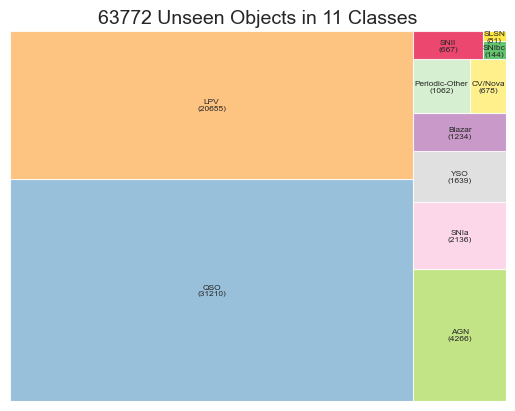

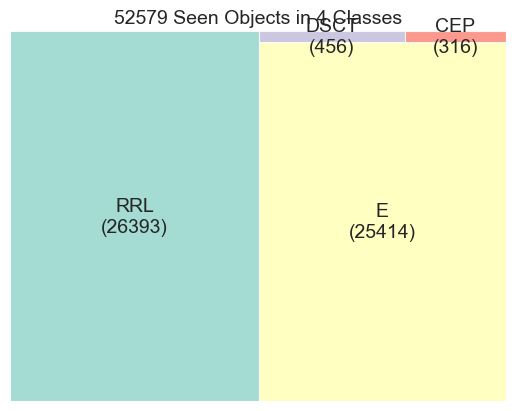

Total anoms:
status
anomalous    63772
normal       52579
Name: count, dtype: int64
********** Check top 200 candidates for each model **********

--- Top 200 candidates for DistClassiPy (min-median) ---


status
anomalous    1.0
Name: proportion, dtype: float64


--- Top 200 candidates for DistClassiPy (min-mean) ---


status
anomalous    1.0
Name: proportion, dtype: float64


--- Top 200 candidates for IsolationForest ---


...

topn:   0%|          | 0/499 [00:00<?, ?it/s]

topn:   0%|          | 0/499 [00:00<?, ?it/s]

topn:   0%|          | 0/499 [00:00<?, ?it/s]

topn:   0%|          | 0/499 [00:00<?, ?it/s]

topn:   0%|          | 0/499 [00:00<?, ?it/s]

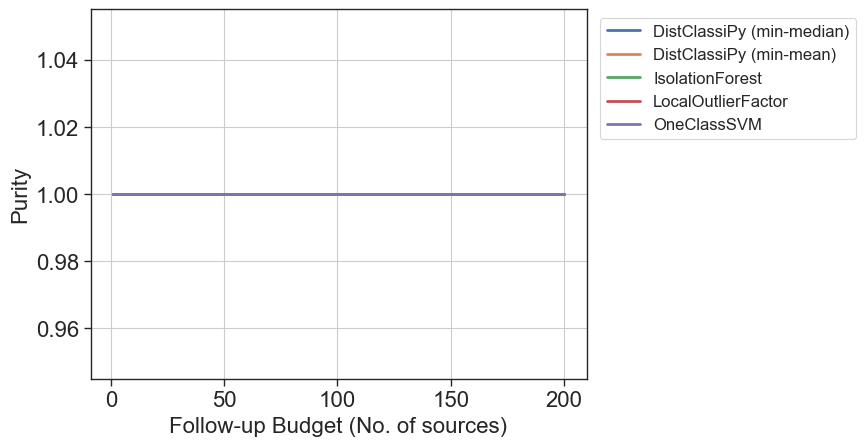

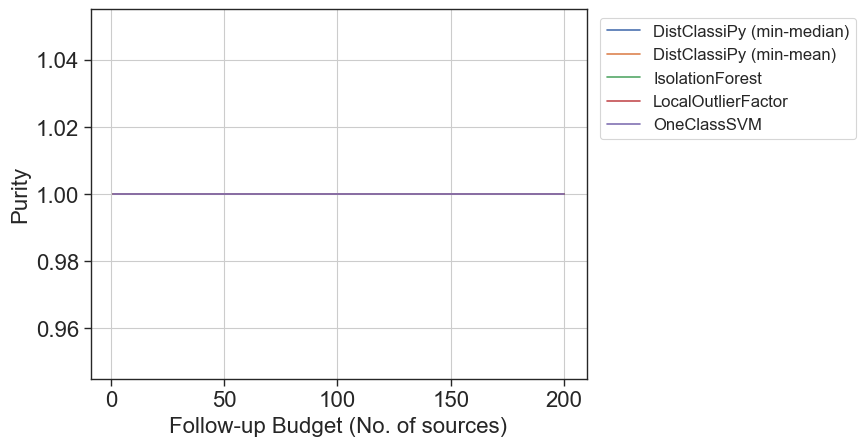

Comparing top 100 DistClassiPy (min-median) with
***DistClassiPy (min-mean)
	Common = 40
	Common % = 40.0%
***IsolationForest
	Common = 12
	Common % = 12.0%
***LocalOutlierFactor
	Common = 3
	Common % = 3.0%
***OneClassSVM
	Common = 1
	Common % = 1.0%
DistClassiPy (min-median) common with top 100 for ALL OTHER: 15 (15.0%)
status
anomalous    85
Name: count, dtype: int64
status
anomalous    1.0
Name: proportion, dtype: float64
score_DistClassiPy (min-median)


,class,status
oid,,
ZTF18abcdajo,LPV,anomalous
ZTF18abmaogt,LPV,anomalous
ZTF18abblrxf,LPV,anomalous
ZTF18abnyuos,LPV,anomalous
ZTF18abqipfx,LPV,anomalous
ZTF19aainfur,LPV,anomalous
ZTF19abvakoa,LPV,anomalous
ZTF18abdlidi,LPV,anomalous
ZTF18abcocsh,LPV,anomalous


score_DistClassiPy (min-mean)


,class,status
oid,,
ZTF18abcdajo,LPV,anomalous
ZTF18abblrxf,LPV,anomalous
ZTF18abnbocw,LPV,anomalous
ZTF17aaafgst,LPV,anomalous
ZTF18abdhxlo,LPV,anomalous
ZTF18aaadvwl,LPV,anomalous
ZTF18abajvxh,LPV,anomalous
ZTF18aaaakat,LPV,anomalous
ZTF18abnykfy,LPV,anomalous


score_IsolationForest


,class,status
oid,,
ZTF18aawacni,LPV,anomalous
ZTF21aaabvit,SNIa,anomalous
ZTF18aavedvo,LPV,anomalous
ZTF18aboewgv,LPV,anomalous
ZTF19aazgshy,LPV,anomalous
ZTF18acjsufo,LPV,anomalous
ZTF19abvakoa,LPV,anomalous
ZTF19achacsy,LPV,anomalous
ZTF19abydbvw,CV/Nova,anomalous


score_LocalOutlierFactor


,class,status
oid,,
ZTF18abcdajo,LPV,anomalous
ZTF18aabgolu,LPV,anomalous
ZTF17aacpcle,LPV,anomalous
ZTF18abmandn,LPV,anomalous
ZTF17aaagser,LPV,anomalous
ZTF18aayvdod,LPV,anomalous
ZTF18abblrxf,LPV,anomalous
ZTF18aalcbvu,LPV,anomalous
ZTF18abmqkxv,LPV,anomalous


score_OneClassSVM


,class,status
oid,,
ZTF19abdbpqq,QSO,anomalous
ZTF18abdlhut,LPV,anomalous
ZTF18abnukgg,LPV,anomalous
ZTF19aaakxnp,LPV,anomalous
ZTF19aawnnjm,QSO,anomalous
ZTF18abhpyqf,LPV,anomalous
ZTF18aazewub,LPV,anomalous
ZTF18abdeupg,LPV,anomalous
ZTF18ablesxe,LPV,anomalous


In [10]:
myknowns = None
myunknowns = None

myfeatures = [
    "SPM_A_2",
    "Multiband_period",
    "g-r_mean",
    "Harmonics_phase_4_2",
    "Harmonics_phase_2_1",
    "Power_rate_4",
]

run_anom_exp(new_knowns=myknowns, new_unknowns=myunknowns,final_features=myfeatures)

Running Models:   0%|          | 0/5 [00:00<?, ?it/s]

How many anomalies in top 100 preds?
********** score_DistClassiPy (min-median) **********


status
anomalous    96
normal        4
Name: count, dtype: int64

********** score_DistClassiPy (min-mean) **********


status
anomalous    100
Name: count, dtype: int64

...

status
anomalous    92
normal        8
Name: count, dtype: int64

********** score_LocalOutlierFactor **********


status
anomalous    95
normal        5
Name: count, dtype: int64

********** score_OneClassSVM **********


status
anomalous    100
Name: count, dtype: int64

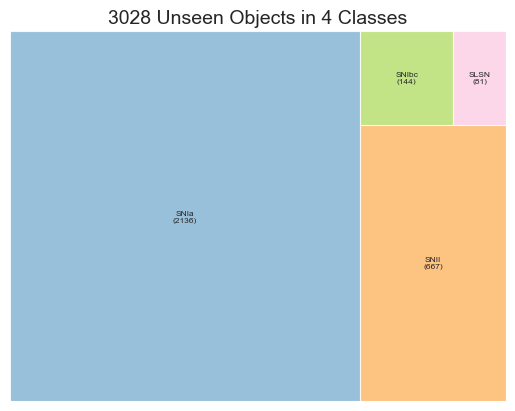

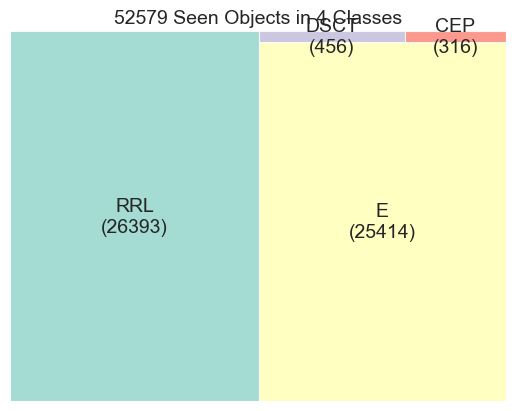

Total anoms:
status
normal       52579
anomalous     3028
Name: count, dtype: int64
********** Check top 200 candidates for each model **********

--- Top 200 candidates for DistClassiPy (min-median) ---


status
anomalous    0.92
normal       0.08
Name: proportion, dtype: float64


--- Top 200 candidates for DistClassiPy (min-mean) ---


status
anomalous    1.0
Name: proportion, dtype: float64


--- Top 200 candidates for IsolationForest ---


...

topn:   0%|          | 0/499 [00:00<?, ?it/s]

topn:   0%|          | 0/499 [00:00<?, ?it/s]

topn:   0%|          | 0/499 [00:00<?, ?it/s]

topn:   0%|          | 0/499 [00:00<?, ?it/s]

topn:   0%|          | 0/499 [00:00<?, ?it/s]

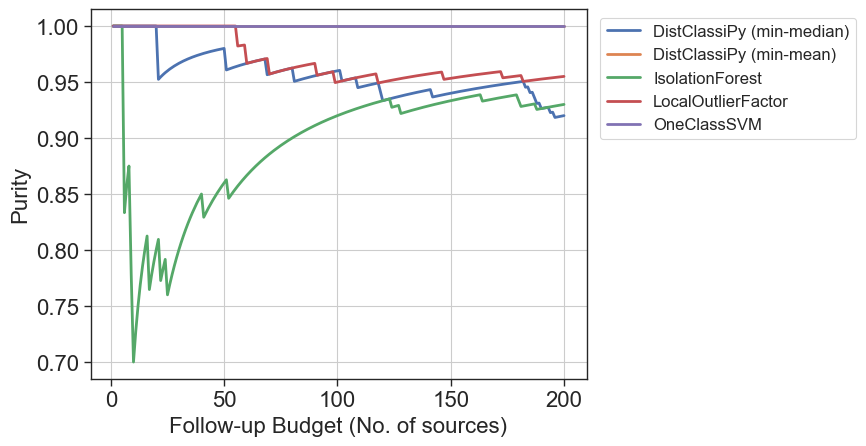

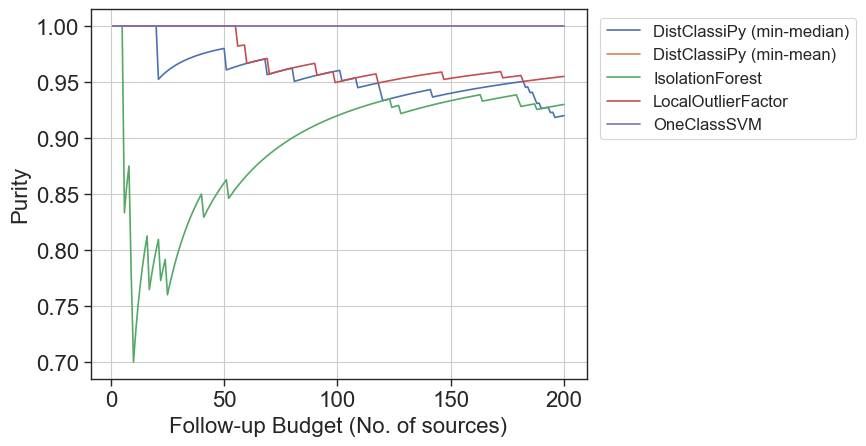

Comparing top 100 DistClassiPy (min-median) with
***DistClassiPy (min-mean)
	Common = 52
	Common % = 52.0%
***IsolationForest
	Common = 15
	Common % = 15.0%
***LocalOutlierFactor
	Common = 22
	Common % = 22.0%
***OneClassSVM
	Common = 29
	Common % = 29.0%
DistClassiPy (min-median) common with top 100 for ALL OTHER: 43 (43.0%)
status
anomalous    53
normal        4
Name: count, dtype: int64
status
anomalous    0.929825
normal       0.070175
Name: proportion, dtype: float64
score_DistClassiPy (min-median)


,class,status
oid,,
ZTF18abqjvyl,SNIa,anomalous
ZTF21abbyhvw,SNIa,anomalous
ZTF18aaslhxt,SNIa,anomalous
ZTF20acnviyk,SNIa,anomalous
ZTF20acnvzga,SNIa,anomalous
ZTF20aczgvcg,SNIa,anomalous
ZTF20acjjkhr,SNIa,anomalous
ZTF18aagtwyh,SNIa,anomalous
ZTF18abjijwk,SNIa,anomalous


score_DistClassiPy (min-mean)


,class,status
oid,,
ZTF18abqjvyl,SNIa,anomalous
ZTF21abbyhvw,SNIa,anomalous
ZTF20aczgvcg,SNIa,anomalous
ZTF20acnvzga,SNIa,anomalous
ZTF18abjijwk,SNIa,anomalous
ZTF18aaslhxt,SNIa,anomalous
ZTF20acnviyk,SNIa,anomalous
ZTF20acjjkhr,SNIa,anomalous
ZTF20aaogrqe,SNIa,anomalous


score_IsolationForest


,class,status
oid,,
ZTF21aaabvit,SNIa,anomalous
ZTF21aaqytjr,SNIa,anomalous
ZTF19aacgslb,SNIa,anomalous
ZTF20achlced,SNIa,anomalous
ZTF21aaahuox,SNIa,anomalous
ZTF18aaaamyg,E,normal
ZTF21aakymbv,SNIbc,anomalous
ZTF20actvlbq,SNIa,anomalous
ZTF19aaqrnad,E,normal


score_LocalOutlierFactor


,class,status
oid,,
ZTF18abqjvyl,SNIa,anomalous
ZTF21abbyhvw,SNIa,anomalous
ZTF20acnvzga,SNIa,anomalous
ZTF20aczgvcg,SNIa,anomalous
ZTF18aaslhxt,SNIa,anomalous
ZTF20acnviyk,SNIa,anomalous
ZTF20acjjkhr,SNIa,anomalous
ZTF18abjijwk,SNIa,anomalous
ZTF20aaybqae,SNIa,anomalous


score_OneClassSVM


,class,status
oid,,
ZTF20aaiaaoi,SNIa,anomalous
ZTF18aaslhxt,SNIa,anomalous
ZTF20acnviyk,SNIa,anomalous
ZTF20acjjkhr,SNIa,anomalous
ZTF20aaogrqe,SNIa,anomalous
ZTF21aayddkn,SNIbc,anomalous
ZTF19acxpuql,SNIbc,anomalous
ZTF20acbiwri,SNII,anomalous
ZTF20abyxcib,SNIa,anomalous


In [13]:
myknowns = ["RRL", "E", "DSCT", "CEP"]
myunknowns = ["SNIa","SNII","SNIbc","SLSN"]


myfeatures = [
    "SPM_A_2",
    "Multiband_period",
    "g-r_mean",
    "Harmonics_phase_4_2",
    "Harmonics_phase_2_1",
    "Power_rate_4",
]

run_anom_exp(new_knowns=myknowns, new_unknowns=myunknowns,final_features=myfeatures)

Running Models:   0%|          | 0/5 [00:00<?, ?it/s]

How many anomalies in top 100 preds?
********** score_DistClassiPy (min-median) **********


status
anomalous    69
normal       31
Name: count, dtype: int64

********** score_DistClassiPy (min-mean) **********


status
anomalous    81
normal       19
Name: count, dtype: int64

...

status
anomalous    58
normal       42
Name: count, dtype: int64

********** score_LocalOutlierFactor **********


status
normal       89
anomalous    11
Name: count, dtype: int64

********** score_OneClassSVM **********


status
anomalous    100
Name: count, dtype: int64

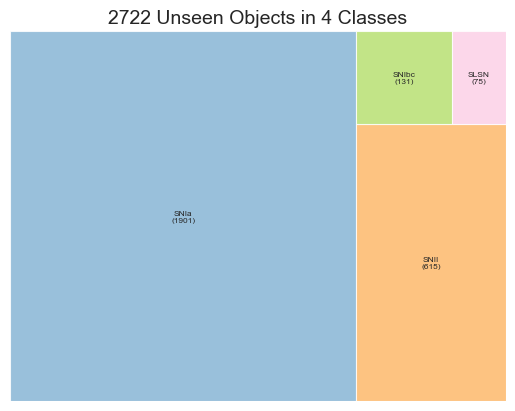

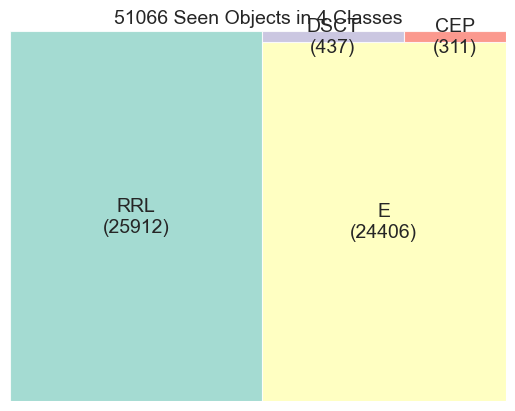

Total anoms:
status
normal       51066
anomalous     2722
Name: count, dtype: int64
********** Check top 200 candidates for each model **********

--- Top 200 candidates for DistClassiPy (min-median) ---


status
anomalous    0.775
normal       0.225
Name: proportion, dtype: float64


--- Top 200 candidates for DistClassiPy (min-mean) ---


status
anomalous    0.865
normal       0.135
Name: proportion, dtype: float64


--- Top 200 candidates for IsolationForest ---


...

topn:   0%|          | 0/499 [00:00<?, ?it/s]

topn:   0%|          | 0/499 [00:00<?, ?it/s]

topn:   0%|          | 0/499 [00:00<?, ?it/s]

topn:   0%|          | 0/499 [00:00<?, ?it/s]

topn:   0%|          | 0/499 [00:00<?, ?it/s]

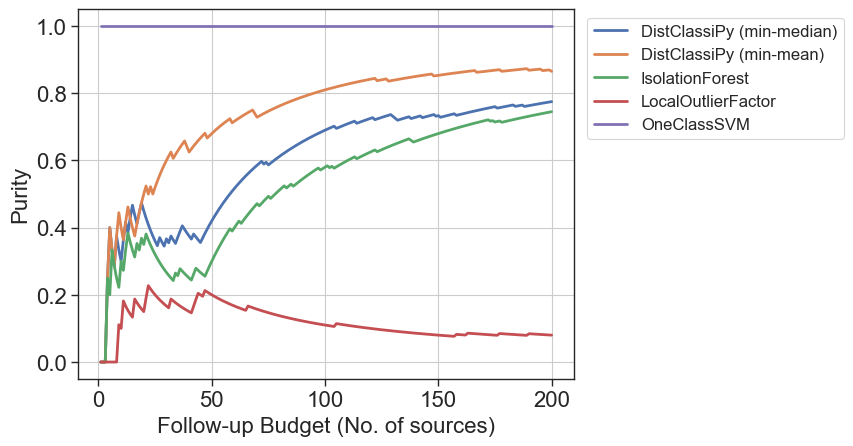

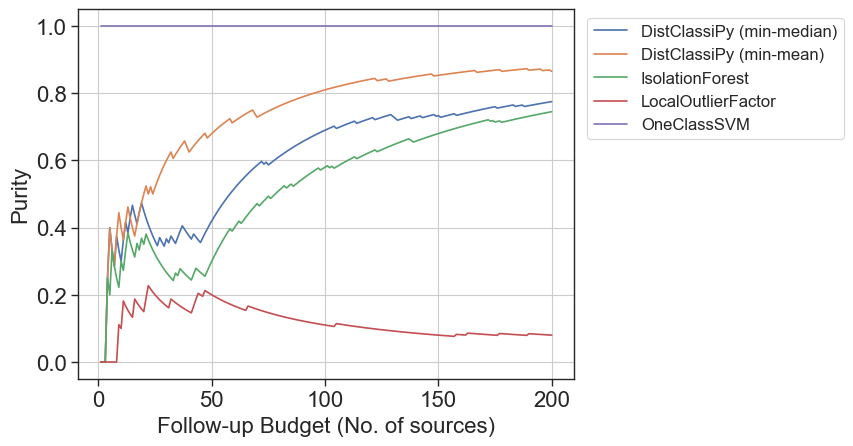

Comparing top 100 DistClassiPy (min-median) with
***DistClassiPy (min-mean)
	Common = 73
	Common % = 73.0%
***IsolationForest
	Common = 58
	Common % = 58.0%
***LocalOutlierFactor
	Common = 13
	Common % = 13.0%
***OneClassSVM
	Common = 41
	Common % = 41.0%
DistClassiPy (min-median) common with top 100 for ALL OTHER: 75 (75.0%)
status
anomalous    20
normal        5
Name: count, dtype: int64
status
anomalous    0.8
normal       0.2
Name: proportion, dtype: float64
score_DistClassiPy (min-median)


,class,status
oid,,
ZTF21aamjcxu,E,normal
ZTF19aayjise,E,normal
ZTF21aahbhly,RRL,normal
ZTF20abijfqq,SNIa,anomalous
ZTF21aaqytjr,SNIa,anomalous
ZTF21aalokhs,E,normal
ZTF18aatmhoi,RRL,normal
ZTF20aaelulu,SNIbc,anomalous
ZTF21aawkccc,RRL,normal


score_DistClassiPy (min-mean)


,class,status
oid,,
ZTF21aamjcxu,E,normal
ZTF19aayjise,E,normal
ZTF21aahbhly,RRL,normal
ZTF21aaqytjr,SNIa,anomalous
ZTF20abijfqq,SNIa,anomalous
ZTF21aalokhs,E,normal
ZTF18aatmhoi,RRL,normal
ZTF21aaabvit,SNIa,anomalous
ZTF20aaelulu,SNIbc,anomalous


score_IsolationForest


,class,status
oid,,
ZTF21aalokhs,E,normal
ZTF18aatpjwi,RRL,normal
ZTF20aakyijk,RRL,normal
ZTF20aavpnlv,SNIa,anomalous
ZTF21aaergch,E,normal
ZTF21aaabvit,SNIa,anomalous
ZTF21aamqteg,RRL,normal
ZTF19aayjise,E,normal
ZTF19abtolir,E,normal


score_LocalOutlierFactor


,class,status
oid,,
ZTF18aakyudk,E,normal
ZTF19acspodo,CEP,normal
ZTF17aabwxlb,RRL,normal
ZTF17aabxkcv,E,normal
ZTF21aamjcxu,E,normal
ZTF19aayjise,E,normal
ZTF21aasxvdv,E,normal
ZTF21aahbhly,RRL,normal
ZTF20abobpcb,SLSN,anomalous


score_OneClassSVM


,class,status
oid,,
ZTF21aaqytjr,SNIa,anomalous
ZTF21aaabvit,SNIa,anomalous
ZTF21aaprfqv,SNIa,anomalous
ZTF20achlced,SNIa,anomalous
ZTF20aaumsrr,SNIa,anomalous
ZTF20aaelulu,SNIbc,anomalous
ZTF19aacgslb,SNIa,anomalous
ZTF20aavpnlv,SNIa,anomalous
ZTF20abijfqq,SNIa,anomalous


In [15]:
myknowns = ["RRL", "E", "DSCT", "CEP"]
myunknowns = ["SNIa","SNII","SNIbc","SLSN"]

myfeatures = ["SPM_A_1",
"SPM_t0_1",
"SPM_gamma_1",
"SPM_beta_1",
"SPM_tau_rise_1",
"SPM_tau_fall_1",
"SPM_chi_1",
"SPM_A_2",
"SPM_t0_2",
"SPM_gamma_2",
"SPM_beta_2",
"SPM_tau_rise_2",
"SPM_tau_fall_2",
"SPM_chi_2"]

knowns=knowns.loc[knowns[myfeatures].dropna().index]
unknowns=unknowns.loc[unknowns[myfeatures].dropna().index]

run_anom_exp(new_knowns=myknowns, new_unknowns=myunknowns,final_features=myfeatures)

### sid thoughts:
- run concrete transient anomaly examples
- try feature selection through best classification features on known classes
- try real ztf data